In [1]:
import os
import sys
import clr
import pandas as pd


# ==========================================================
# 1. CONFIGURACIÓN DE LA CONSULTA
# ==========================================================

TAGS = [

    # ======================================================
    # BALANCE DE VAPOR
    # ======================================================

    # Vapor MS importado desde límite de batería
    "FCCFI30303BM.DACA.PV",

    # Vapor MS exportado desde FCC
    "FCCFI30303AM.DACA.PV",

    # Vapor MS generado dentro de FCC
    "FCCFI12901M.DACA.PV",

    # Consumo de vapor compresor de gases
    "RG1FI00303.DACA.PV",


    # ======================================================
    # CONDENSADOR / VACÍO
    # ======================================================

    # Presión absoluta del condensador
    "FCCPI13162M.PV",

    # Flujo de agua de mar
    "FCCFI30202.DACA.PV",

    # Temperatura entrada agua de mar
    "FCCTI30204.DACA.PV",

    # Temperatura salida agua de mar
    "FCCTI30208.DACA.PV",

    # Presión entrada agua de mar
    "FCCPI30204.DACA.PV",


    # ======================================================
    # SOPLADOR / TURBINA
    # ======================================================

    # Flujo de aire del soplador
    "FCCFI10561M.DACA.PV",

    # Temperatura descarga soplador
    "FCCTI10464.PV",

    # Presión descarga soplador
    "FCCPI10463.PV",

    # RPM turbina
    "FCCSI70129B.PV",

    # Presión vapor entrada turbina
    "FCCPI10405M.PV",

    # Temperatura vapor entrada turbina
    "FCCTI10401M.PV",

    # Apertura antisurge
    "FCCZI10461.PV",


    # ======================================================
    # REGENERADOR
    # ======================================================

    # Presión regenerador
    "FCCPC11203.PIDA.PV",

    # Posición válvula SV3
    "FCCPDX12601B.DACA.PV",


    # ======================================================
    # EYECTORES
    # ======================================================

    # Presión vapor MS hacia eyectores
    "FCCPI30304.DACA.PV",

    # Temperatura vapor MS hacia eyectores
    "FCCTI30304.DACA.PV",
]


# ==========================================================
# 2. RANGO DE TIEMPO
# ==========================================================

INICIO = "2026-05-01 00:00:00"
FIN = "2026-08-18 23:59:00"


# ==========================================================
# 3. INTERVALO
# ==========================================================

INTERVALO_MIN = 1


# ==========================================================
# 4. TIPO DE MUESTREO
# ==========================================================

# "Average"  = promedio dentro de cada intervalo
# "Snapshot" = valor puntual

TIPO_MUESTREO = "Average"


# ==========================================================
# 5. CONSUMO NOMINAL BOMBA DE FONDOS
# ==========================================================

CONSUMO_BOMBA_FONDOS = 8396  # kg/h


# ==========================================================
# 6. CONFIGURACIÓN DE UNIFORMANCE PHD
# ==========================================================

RUTA = r"C:\Program Files\Honeywell\Uniformance\Excel Companion"

if RUTA not in sys.path:
    sys.path.append(RUTA)

if hasattr(os, "add_dll_directory"):
    dll_dir = os.add_dll_directory(RUTA)

clr.AddReference(
    os.path.join(
        RUTA,
        "phdapinet.dll"
    )
)


# ==========================================================
# 7. IMPORTAR CLASES DE UNIFORMANCE
# ==========================================================

from Uniformance.PHD import (
    PHDServer,
    PHDHistorian,
    Tag,
    SERVERVERSION,
    SAMPLETYPE,
    REDUCTIONTYPE,
    REDUCTIONOFFSET
)


# ==========================================================
# 8. CONECTAR AL SERVIDOR PHD
# ==========================================================

print("Conectando al PHD...")

server = PHDServer(
    "10.2.18.69",
    SERVERVERSION.RAPI200
)

server.ConnectToServer()

print("✅ Conectado al PHD")
print("Servidor:", server.HostName)
print("Puerto:", server.Port)
print("API:", server.APIVersion)


# ==========================================================
# 9. CONFIGURAR CONSULTA HISTÓRICA
# ==========================================================

historian = PHDHistorian()

historian.DefaultServer = server
historian.StartTime = INICIO
historian.EndTime = FIN

historian.SampleFrequency = INTERVALO_MIN * 60
historian.UseSampleFrequency = True


# ==========================================================
# 10. DEFINIR TIPO DE MUESTREO
# ==========================================================

if TIPO_MUESTREO.lower() == "average":

    historian.Sampletype = SAMPLETYPE.Average

elif TIPO_MUESTREO.lower() == "snapshot":

    historian.Sampletype = SAMPLETYPE.Snapshot

else:

    raise ValueError(
        "TIPO_MUESTREO debe ser 'Average' o 'Snapshot'"
    )


print("\nCONFIGURACIÓN DE CONSULTA")
print("--------------------------")
print("Inicio:", INICIO)
print("Fin:", FIN)
print("Intervalo:", INTERVALO_MIN, "minuto(s)")
print("Tipo:", TIPO_MUESTREO)
print("Número de tags:", len(TAGS))


# ==========================================================
# 11. FUNCIÓN PARA CONSULTAR UN TAG
# ==========================================================

def obtener_tag(nombre_tag):

    print(f"\nConsultando: {nombre_tag}")

    tag = Tag()

    tag.TagName = nombre_tag
    tag.Server = server

    tag.ReductionType = getattr(
        REDUCTIONTYPE,
        "None"
    )

    tag.ReductionFrequency = 0
    tag.ReductionOffset = REDUCTIONOFFSET.Before


    # ======================================================
    # CONSULTAR PHD
    # ======================================================

    datos = historian.FetchDataList(tag)


    # ======================================================
    # CONVERTIR DATOS .NET A PYTHON
    # ======================================================

    timestamps = list(datos.Timestamps)
    valores = list(datos.DataValues)


    # ======================================================
    # CREAR DATAFRAME DEL TAG
    # ======================================================

    df_tag = pd.DataFrame({

        "Timestamp_PHD": timestamps,

        nombre_tag: valores
    })


    # ======================================================
    # CONVERTIR TIMESTAMP PHD A FECHA/HORA
    # ======================================================

    df_tag["FechaHora"] = pd.to_datetime(

        df_tag["Timestamp_PHD"],

        unit="D",

        origin="1899-12-30"

    ).dt.round("min")


    # ======================================================
    # ELIMINAR TIMESTAMP NUMÉRICO
    # ======================================================

    df_tag = df_tag.drop(
        columns=["Timestamp_PHD"]
    )


    # ======================================================
    # SI EXISTE MÁS DE UN DATO EN EL MISMO MINUTO
    # USAR EL PROMEDIO
    # ======================================================

    df_tag = (

        df_tag

        .groupby(
            "FechaHora",
            as_index=False
        )[nombre_tag]

        .mean()
    )


    print(
        f"✅ {len(df_tag)} datos obtenidos"
    )

    return df_tag


# ==========================================================
# 12. CONSULTAR TODOS LOS TAGS
# ==========================================================

dataframes = []

for nombre_tag in TAGS:

    try:

        df_tag = obtener_tag(nombre_tag)

        dataframes.append(df_tag)

    except Exception as e:

        print(
            f"\n❌ Error consultando {nombre_tag}"
        )

        print(e)


# ==========================================================
# 13. VERIFICAR QUE HAYA DATOS
# ==========================================================

if len(dataframes) == 0:

    raise RuntimeError(
        "No se pudo obtener información de ningún tag."
    )


# ==========================================================
# 14. UNIR TODOS LOS TAGS POR FECHA/HORA
# ==========================================================

df = dataframes[0]

for df_tag in dataframes[1:]:

    df = pd.merge(

        df,

        df_tag,

        on="FechaHora",

        how="outer"
    )


# ==========================================================
# 15. ORDENAR RESULTADOS
# ==========================================================

df = (

    df

    .sort_values("FechaHora")

    .reset_index(drop=True)
)


# ==========================================================
# 16. CAMBIAR NOMBRES DE COLUMNAS
# ==========================================================

df = df.rename(columns={

    # ======================================================
    # BALANCE DE VAPOR
    # ======================================================

    "FCCFI30303BM.DACA.PV":
        "Vapor_MS_Importado_kg_h",

    "FCCFI30303AM.DACA.PV":
        "Vapor_MS_Exportado_kg_h",

    "FCCFI12901M.DACA.PV":
        "Vapor_MS_Generado_kg_h",

    "RG1FI00303.DACA.PV":
        "Vapor_Compresor_Gases_kg_h",


    # ======================================================
    # CONDENSADOR
    # ======================================================

    "FCCPI13162M.PV":
        "Presion_Condensador_kg_cm2A",

    "FCCFI30202.DACA.PV":
        "Flujo_Agua_Mar_m3_h",

    "FCCTI30204.DACA.PV":
        "Temp_Entrada_Agua_Mar_C",

    "FCCTI30208.DACA.PV":
        "Temp_Salida_Agua_Mar_C",

    "FCCPI30204.DACA.PV":
        "Presion_Entrada_Agua_Mar_kg_cm2",


    # ======================================================
    # SOPLADOR / TURBINA
    # ======================================================

    "FCCFI10561M.DACA.PV":
        "Flujo_Aire_Soplador_kg_h",

    "FCCTI10464.PV":
        "Temp_Descarga_Soplador_C",

    "FCCPI10463.PV":
        "Presion_Descarga_Soplador_kg_cm2",

    "FCCSI70129B.PV":
        "RPM_Turbina",

    "FCCPI10405M.PV":
        "Presion_Vapor_Entrada_Turbina_kg_cm2",

    "FCCTI10401M.PV":
        "Temp_Vapor_Entrada_Turbina_C",

    "FCCZI10461.PV":
        "Apertura_Antisurge_pct",


    # ======================================================
    # REGENERADOR
    # ======================================================

    "FCCPC11203.PIDA.PV":
        "Presion_Regenerador_kg_cm2",

    "FCCPDX12601B.DACA.PV":
        "Apertura_SV3_pct",


    # ======================================================
    # EYECTORES
    # ======================================================

    "FCCPI30304.DACA.PV":
        "Presion_MS_Eyectores_kg_cm2",

    "FCCTI30304.DACA.PV":
        "Temp_MS_Eyectores_C"
})


# ==========================================================
# 17. CALCULAR CONSUMO DE VAPOR DE LA TURBINA
# ==========================================================
#
# Vapor turbina soplador =
#
#   Vapor MS importado
# - Vapor MS exportado
# + Vapor MS generado
# - Vapor compresor gases
# - Vapor bomba de fondos
#
# ==========================================================

df["Flujo_Vapor_Turbina_kg_h"] = (

    df["Vapor_MS_Importado_kg_h"]

    - df["Vapor_MS_Exportado_kg_h"]

    + df["Vapor_MS_Generado_kg_h"]

    - df["Vapor_Compresor_Gases_kg_h"]

    - CONSUMO_BOMBA_FONDOS
)


# ==========================================================
# 18. CONVERTIR CONSUMO A TONELADAS/HORA
# ==========================================================

df["Flujo_Vapor_Turbina_t_h"] = (

    df["Flujo_Vapor_Turbina_kg_h"]

    / 1000
)


# ==========================================================
# 19. CREAR VARIABLE ΔT DEL AGUA DE MAR
# ==========================================================

df["DeltaT_Agua_Mar_C"] = (

    df["Temp_Salida_Agua_Mar_C"]

    - df["Temp_Entrada_Agua_Mar_C"]
)


# ==========================================================
# 20. ORDENAR COLUMNAS
# ==========================================================

columnas_finales = [

    "FechaHora",


    # ======================================================
    # CONSUMO VAPOR TURBINA
    # ======================================================

    "Flujo_Vapor_Turbina_t_h",
    "Flujo_Vapor_Turbina_kg_h",


    # ======================================================
    # CONDENSADOR / VACÍO
    # ======================================================

    "Presion_Condensador_kg_cm2A",


    # ======================================================
    # SOPLADOR
    # ======================================================

    "Flujo_Aire_Soplador_kg_h",
    "Temp_Descarga_Soplador_C",
    "Presion_Descarga_Soplador_kg_cm2",
    "RPM_Turbina",


    # ======================================================
    # VAPOR TURBINA
    # ======================================================

    "Presion_Vapor_Entrada_Turbina_kg_cm2",
    "Temp_Vapor_Entrada_Turbina_C",


    # ======================================================
    # CONDENSADOR / AGUA DE MAR
    # ======================================================

    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "DeltaT_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",


    # ======================================================
    # REGENERADOR
    # ======================================================

    "Presion_Regenerador_kg_cm2",
    "Apertura_SV3_pct",


    # ======================================================
    # ANTISURGE
    # ======================================================

    "Apertura_Antisurge_pct",


    # ======================================================
    # EYECTORES
    # ======================================================

    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",


    # ======================================================
    # BALANCE DE VAPOR ORIGINAL
    # ======================================================

    "Vapor_MS_Importado_kg_h",
    "Vapor_MS_Exportado_kg_h",
    "Vapor_MS_Generado_kg_h",
    "Vapor_Compresor_Gases_kg_h"
]


df = df[columnas_finales]


# ==========================================================
# 21. MOSTRAR RESULTADO FINAL
# ==========================================================

print("\n")
print("=" * 80)
print("✅ CONSULTA PHD TERMINADA")
print("=" * 80)

print(
    "\nCantidad de registros:",
    len(df)
)

print(
    "\nNúmero de variables:",
    len(df.columns)
)

print("\nPrimeros registros:\n")

print(
    df.head(20).to_string(
        index=False
    )
)


# ==========================================================
# 22. RESUMEN CONSUMO DE VAPOR
# ==========================================================

print("\n")
print("=" * 80)
print("CONSUMO CALCULADO DE VAPOR - TURBINA SOPLADOR")
print("=" * 80)

print(
    df["Flujo_Vapor_Turbina_t_h"].describe()
)


# ==========================================================
# 23. DATAFRAME FINAL
# ==========================================================

df

Conectando al PHD...
✅ Conectado al PHD
Servidor: 10.2.18.69
Puerto: 3150
API: RAPI200

CONFIGURACIÓN DE CONSULTA
--------------------------
Inicio: 2026-05-01 00:00:00
Fin: 2026-08-18 23:59:00
Intervalo: 1 minuto(s)
Tipo: Average
Número de tags: 20

Consultando: FCCFI30303BM.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCFI30303AM.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCFI12901M.DACA.PV
✅ 158400 datos obtenidos

Consultando: RG1FI00303.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCPI13162M.PV
✅ 158400 datos obtenidos

Consultando: FCCFI30202.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCTI30204.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCTI30208.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCPI30204.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCFI10561M.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCTI10464.PV
✅ 158400 datos obtenidos

Consultando: FCCPI10463.PV
✅ 158400 datos obtenidos

Consultando: FCCSI70129B.PV
✅ 158400 datos obtenidos

Consult

,FechaHora,Flujo_Vapor_Turbina_t_h,Flujo_Vapor_Turbina_kg_h,Presion_Condensador_kg_cm2A,Flujo_Aire_Soplador_kg_h,Temp_Descarga_Soplador_C,Presion_Descarga_Soplador_kg_cm2,RPM_Turbina,Presion_Vapor_Entrada_Turbina_kg_cm2,Temp_Vapor_Entrada_Turbina_C,...,Presion_Entrada_Agua_Mar_kg_cm2,Presion_Regenerador_kg_cm2,Apertura_SV3_pct,Apertura_Antisurge_pct,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Vapor_MS_Importado_kg_h,Vapor_MS_Exportado_kg_h,Vapor_MS_Generado_kg_h,Vapor_Compresor_Gases_kg_h
0,2026-05-01 00:00:00,33.880236,33880.236328,0.050061,124478.617188,164.764969,2.306471,5324.481445,40.961540,343.826324,...,6.053902,1.860262,33.818588,33.690475,10.859919,259.716370,27983.869141,0.0,25265.792969,10973.425781
1,2026-05-01 00:01:00,33.909539,33909.539062,0.050061,124495.304688,164.722229,2.311355,5327.228516,41.034798,344.341431,...,6.055304,1.859373,33.853645,33.693527,10.850438,259.711914,28253.207031,0.0,25024.755859,10972.423828
2,2026-05-01 00:02:00,33.890573,33890.573242,0.050061,124501.570312,164.775650,2.310440,5324.786621,41.028694,344.207886,...,6.058653,1.860790,33.451866,33.678265,10.849522,259.734131,26953.349609,0.0,26328.285156,10995.061523
3,2026-05-01 00:03:00,33.864421,33864.420898,0.050061,124296.460938,164.786331,2.310440,5327.839355,41.028694,344.150665,...,6.047906,1.863403,33.752090,33.659950,10.841509,259.713043,27364.400391,0.0,25875.843750,10979.823242
4,2026-05-01 00:04:00,33.979686,33979.685547,0.050137,124659.398438,164.797012,2.311661,5327.839355,41.047009,344.074341,...,6.028671,1.865417,34.112686,33.565327,10.832578,259.678558,27786.103516,0.0,25561.562500,10971.980469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158395,2026-08-18 23:55:00,33.676523,33676.523438,0.084249,97973.296875,168.557693,2.432235,5324.481445,40.268620,341.517883,...,6.567516,2.129689,12.346967,42.689255,11.241217,262.886902,31711.203125,0.0,21114.789062,10753.468750
158396,2026-08-18 23:56:00,33.668102,33668.101562,0.084249,97982.343750,168.547012,2.429487,5329.060059,40.225883,341.327087,...,6.579158,2.127160,12.924597,42.725883,11.212591,262.879120,31767.919922,0.0,21035.414062,10739.232422
158397,2026-08-18 23:57:00,33.522654,33522.654297,0.084325,98033.789062,168.557693,2.426435,5324.481445,40.216728,341.422485,...,6.550850,2.125146,12.390930,42.710625,11.213753,262.901367,31749.892578,0.0,20897.259766,10728.498047
158398,2026-08-18 23:58:00,33.394415,33394.415039,0.084783,97990.687500,168.611115,2.430403,5323.565430,40.195362,341.517883,...,6.561987,2.126271,12.957150,42.689255,11.197851,262.933594,31761.769531,0.0,20771.935547,10743.290039


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158400 entries, 0 to 158399
Data columns (total 24 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   FechaHora                             158400 non-null  datetime64[ns]
 1   Flujo_Vapor_Turbina_t_h               158400 non-null  float64       
 2   Flujo_Vapor_Turbina_kg_h              158400 non-null  float64       
 3   Presion_Condensador_kg_cm2A           158400 non-null  float64       
 4   Flujo_Aire_Soplador_kg_h              158400 non-null  float64       
 5   Temp_Descarga_Soplador_C              158400 non-null  float64       
 6   Presion_Descarga_Soplador_kg_cm2      158400 non-null  float64       
 7   RPM_Turbina                           158400 non-null  float64       
 8   Presion_Vapor_Entrada_Turbina_kg_cm2  158400 non-null  float64       
 9   Temp_Vapor_Entrada_Turbina_C          158400 non-null  float64       


In [3]:
df.shape

(158400, 24)

In [4]:
# ============================================================
# AGREGAR COLUMNA ESTADO_OPERACION
# ============================================================

# Ordenar cronológicamente
df = df.sort_values("FechaHora").reset_index(drop=True)


# ============================================================
# 1. CONDICIÓN BÁSICA DE SERVICIO
# ============================================================

condicion_servicio = (
    (df["RPM_Turbina"] >= 5000) &
    (df["Flujo_Aire_Soplador_kg_h"] > 50000)
)


# ============================================================
# 2. DETECTAR EL INICIO DE CADA ARRANQUE
# ============================================================

inicio_servicio = (
    condicion_servicio &
    ~condicion_servicio.shift(1, fill_value=False)
)


# ============================================================
# 3. IDENTIFICAR CADA BLOQUE DE OPERACIÓN
# ============================================================

bloque_servicio = inicio_servicio.cumsum()


# ============================================================
# 4. OBTENER HORA DE INICIO DE CADA BLOQUE
# ============================================================

hora_inicio = (
    df["FechaHora"]
    .where(inicio_servicio)
    .groupby(bloque_servicio)
    .transform("first")
)


# ============================================================
# 5. CALCULAR MINUTOS DESDE EL ARRANQUE
# ============================================================

minutos_desde_inicio = (
    (df["FechaHora"] - hora_inicio)
    .dt.total_seconds()
    / 60
)


# ============================================================
# 6. CREAR ESTADO OPERACIONAL
# ============================================================

df["Estado_Operacion"] = "FUERA_DE_SERVICIO"


# Primeros 30 minutos después de alcanzar condición de servicio
df.loc[
    condicion_servicio &
    (minutos_desde_inicio < 30),
    "Estado_Operacion"
] = "ARRANQUE_TRANSITORIO"


# Después de 30 minutos
df.loc[
    condicion_servicio &
    (minutos_desde_inicio >= 30),
    "Estado_Operacion"
] = "EN_SERVICIO"


# ============================================================
# 7. REVISAR RESULTADO
# ============================================================

print(df["Estado_Operacion"].value_counts())

print("\nNuevo tamaño del dataframe:")
print(df.shape)

Estado_Operacion
EN_SERVICIO             126801
FUERA_DE_SERVICIO        31297
ARRANQUE_TRANSITORIO       302
Name: count, dtype: int64

Nuevo tamaño del dataframe:
(158400, 25)


In [8]:
# ============================================================
# MODELO 1 - FILTRAR SOLO ESTADO EN SERVICIO
# ============================================================

df_operacion = df[
    df["Estado_Operacion"] == "EN_SERVICIO"
].copy()

# Ordenar cronológicamente
df_operacion = (
    df_operacion
    .sort_values("FechaHora")
    .reset_index(drop=True)
)

print("Registros totales:", len(df))
print("Registros EN_SERVICIO:", len(df_operacion))
print("Columnas:", len(df_operacion.columns))

df_operacion.head()

Registros totales: 158400
Registros EN_SERVICIO: 126801
Columnas: 25


,FechaHora,Flujo_Vapor_Turbina_t_h,Flujo_Vapor_Turbina_kg_h,Presion_Condensador_kg_cm2A,Flujo_Aire_Soplador_kg_h,Temp_Descarga_Soplador_C,Presion_Descarga_Soplador_kg_cm2,RPM_Turbina,Presion_Vapor_Entrada_Turbina_kg_cm2,Temp_Vapor_Entrada_Turbina_C,...,Presion_Regenerador_kg_cm2,Apertura_SV3_pct,Apertura_Antisurge_pct,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Vapor_MS_Importado_kg_h,Vapor_MS_Exportado_kg_h,Vapor_MS_Generado_kg_h,Vapor_Compresor_Gases_kg_h,Estado_Operacion
0,2026-05-01 00:30:00,33.878177,33878.176758,0.050672,124363.203125,164.797012,2.315018,5329.670410,40.952381,344.036194,...,1.863236,33.735947,33.525642,10.870131,259.046875,26768.228516,0.0,26483.992188,10978.043945,EN_SERVICIO
1,2026-05-01 00:31:00,34.028234,34028.234375,0.050595,124425.093750,164.786331,2.308303,5324.481445,40.958485,344.169739,...,1.862430,34.461880,33.528694,10.853128,259.011292,26813.822266,0.0,26596.685547,10986.273438,EN_SERVICIO
2,2026-05-01 00:32:00,34.173309,34173.308594,0.050214,124450.117188,164.786331,2.303419,5323.565430,40.998169,344.284210,...,1.862527,34.531162,33.528694,10.845239,258.969055,27071.474609,0.0,26495.285156,10997.451172,EN_SERVICIO
3,2026-05-01 00:33:00,33.965320,33965.320312,0.050519,124494.617188,164.786331,2.303724,5323.565430,41.013432,344.131592,...,1.861221,34.444355,33.525642,10.849460,258.936798,26407.746094,0.0,26917.992188,10964.417969,EN_SERVICIO
4,2026-05-01 00:34:00,33.820271,33820.270508,0.050137,124409.796875,164.786331,2.308608,5323.565430,40.955433,343.788177,...,1.861457,33.843349,33.507324,10.827134,258.926788,25865.099609,0.0,27313.640625,10962.469727,EN_SERVICIO


In [9]:
# ============================================================
# VARIABLE OBJETIVO
# ============================================================

objetivo = "Presion_Condensador_kg_cm2A"
# ============================================================
# VARIABLES PREDICTORAS DEL MODELO 1
# ============================================================

variables_modelo1 = [

    # Sistema de agua de mar
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",

    # Vapor hacia eyectores
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",

    # Carga del soplador
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2"
]

In [10]:
# ============================================================
# CREAR DATAFRAME DEL MODELO 1
# ============================================================

df_modelo1 = df_operacion[
    ["FechaHora"] +
    variables_modelo1 +
    [objetivo]
].copy()

df_modelo1 = (
    df_modelo1
    .sort_values("FechaHora")
    .reset_index(drop=True)
)

print("Registros para Modelo 1:", len(df_modelo1))
print("Número de columnas:", len(df_modelo1.columns))

df_modelo1.head()

Registros para Modelo 1: 126801
Número de columnas: 10


,FechaHora,Flujo_Agua_Mar_m3_h,Temp_Entrada_Agua_Mar_C,Temp_Salida_Agua_Mar_C,Presion_Entrada_Agua_Mar_kg_cm2,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Flujo_Aire_Soplador_kg_h,Presion_Descarga_Soplador_kg_cm2,Presion_Condensador_kg_cm2A
0,2026-05-01 00:30:00,4121.230469,21.037535,26.636131,6.046231,10.870131,259.046875,124363.203125,2.315018,0.050672
1,2026-05-01 00:31:00,4123.942383,21.037313,26.657045,6.030656,10.853128,259.011292,124425.093750,2.308303,0.050595
2,2026-05-01 00:32:00,4122.454102,21.027523,26.660828,6.072553,10.845239,258.969055,124450.117188,2.303419,0.050214
3,2026-05-01 00:33:00,4130.617188,21.020185,26.637241,6.058380,10.849460,258.936798,124494.617188,2.303724,0.050519
4,2026-05-01 00:34:00,4128.072266,21.006832,26.645920,6.040936,10.827134,258.926788,124409.796875,2.308608,0.050137


In [11]:
# ============================================================
# COMPROBACIÓN DEL DATASET - MODELO 1
# ============================================================

print("Rango de fechas")
print("-------------------------")
print("Inicio:", df_modelo1["FechaHora"].min())
print("Fin:   ", df_modelo1["FechaHora"].max())

print("\nRegistros:", len(df_modelo1))


# ============================================================
# ESTADÍSTICA DE LA PRESIÓN DEL CONDENSADOR
# ============================================================

print("\nPresión del condensador")
print("-------------------------")

print(
    df_modelo1["Presion_Condensador_kg_cm2A"].describe()
)

Rango de fechas
-------------------------
Inicio: 2026-05-01 00:30:00
Fin:    2026-08-18 23:59:00

Registros: 126801

Presión del condensador
-------------------------
count    126801.000000
mean          0.101544
std           0.048887
min           0.015263
25%           0.067689
50%           0.088294
75%           0.111264
max           0.926358
Name: Presion_Condensador_kg_cm2A, dtype: float64


In [12]:
# ============================================================
# 5. DIVISIÓN TEMPORAL TRAIN / TEST
# MODELO 1
# ============================================================

# El dataframe ya está ordenado por FechaHora

punto_corte = int(len(df_modelo1) * 0.90)

train = df_modelo1.iloc[:punto_corte].copy()
test  = df_modelo1.iloc[punto_corte:].copy()


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print("TRAIN")
print("--------------------")
print("Inicio:", train["FechaHora"].min())
print("Fin:   ", train["FechaHora"].max())
print("Registros:", len(train))

print("\nTEST")
print("--------------------")
print("Inicio:", test["FechaHora"].min())
print("Fin:   ", test["FechaHora"].max())
print("Registros:", len(test))

TRAIN
--------------------
Inicio: 2026-05-01 00:30:00
Fin:    2026-07-31 12:49:00
Registros: 114120

TEST
--------------------
Inicio: 2026-07-31 12:50:00
Fin:    2026-08-18 23:59:00
Registros: 12681


In [13]:
# ============================================================
# 6. CREAR X_train, y_train, X_test, y_test
# ============================================================

X_train = train[variables_modelo1].copy()
y_train = train[objetivo].copy()

X_test = test[variables_modelo1].copy()
y_test = test[objetivo].copy()


# ============================================================
# COMPROBAR DIMENSIONES
# ============================================================

print("TRAIN")
print("--------------------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTEST")
print("--------------------")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

TRAIN
--------------------
X_train: (114120, 8)
y_train: (114120,)

TEST
--------------------
X_test: (12681, 8)
y_test: (12681,)


In [14]:
# ============================================================
# 7. COMPARAR RANGOS DE VARIABLES ENTRE TRAIN Y TEST
# ============================================================

import pandas as pd

comparacion = pd.DataFrame({
    "Train_Min": X_train.min(),
    "Train_Media": X_train.mean(),
    "Train_Max": X_train.max(),
    
    "Test_Min": X_test.min(),
    "Test_Media": X_test.mean(),
    "Test_Max": X_test.max()
})

comparacion = comparacion.round(3)

comparacion

,Train_Min,Train_Media,Train_Max,Test_Min,Test_Media,Test_Max
Flujo_Agua_Mar_m3_h,1187.297,3351.119,5000.000,2795.646,3559.978,5000.000
Temp_Entrada_Agua_Mar_C,19.144,22.230,25.770,19.402,21.364,24.514
Temp_Salida_Agua_Mar_C,24.071,29.558,47.595,23.894,27.599,32.153
Presion_Entrada_Agua_Mar_kg_cm2,4.090,6.289,7.533,5.168,6.457,7.508
Presion_MS_Eyectores_kg_cm2,9.632,11.097,12.490,9.930,11.171,11.975
Temp_MS_Eyectores_C,226.254,252.906,280.378,241.083,261.473,289.875
Flujo_Aire_Soplador_kg_h,59288.816,116327.665,149569.062,66781.117,96656.097,107466.609
Presion_Descarga_Soplador_kg_cm2,1.031,2.292,3.064,1.099,2.150,2.497


In [15]:
# ============================================================
# 8. ENTRENAMIENTO - MODELO 1 RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np


# ============================================================
# CREAR MODELO
# ============================================================

modelo_rf_vacio = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# ENTRENAR
# ============================================================

modelo_rf_vacio.fit(X_train, y_train)


# ============================================================
# PREDICCIÓN SOBRE TEST
# ============================================================

y_pred = modelo_rf_vacio.predict(X_test)


# ============================================================
# MÉTRICAS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)


# ============================================================
# RESULTADOS
# ============================================================

print("MODELO 1 - RANDOM FOREST")
print("----------------------------")

print(f"MAE  : {mae:.6f} kg/cm²A")
print(f"RMSE : {rmse:.6f} kg/cm²A")
print(f"R²   : {r2:.4f}")

MODELO 1 - RANDOM FOREST
----------------------------
MAE  : 0.023224 kg/cm²A
RMSE : 0.028513 kg/cm²A
R²   : -0.1869


In [16]:
# ============================================================
# 9. CREAR DATAFRAME DE RESULTADOS DEL TEST
# ============================================================

resultado_test = test[["FechaHora", objetivo]].copy()

resultado_test["Presion_Predicha"] = y_pred

resultado_test["Error_Absoluto"] = abs(
    resultado_test[objetivo] -
    resultado_test["Presion_Predicha"]
)

resultado_test.head()

,FechaHora,Presion_Condensador_kg_cm2A,Presion_Predicha,Error_Absoluto
114120,2026-07-31 12:50:00,0.054258,0.055039,0.000780
114121,2026-07-31 12:51:00,0.053877,0.055654,0.001777
114122,2026-07-31 12:52:00,0.054258,0.055738,0.001480
114123,2026-07-31 12:53:00,0.054335,0.055322,0.000988
114124,2026-07-31 12:54:00,0.054258,0.055454,0.001195


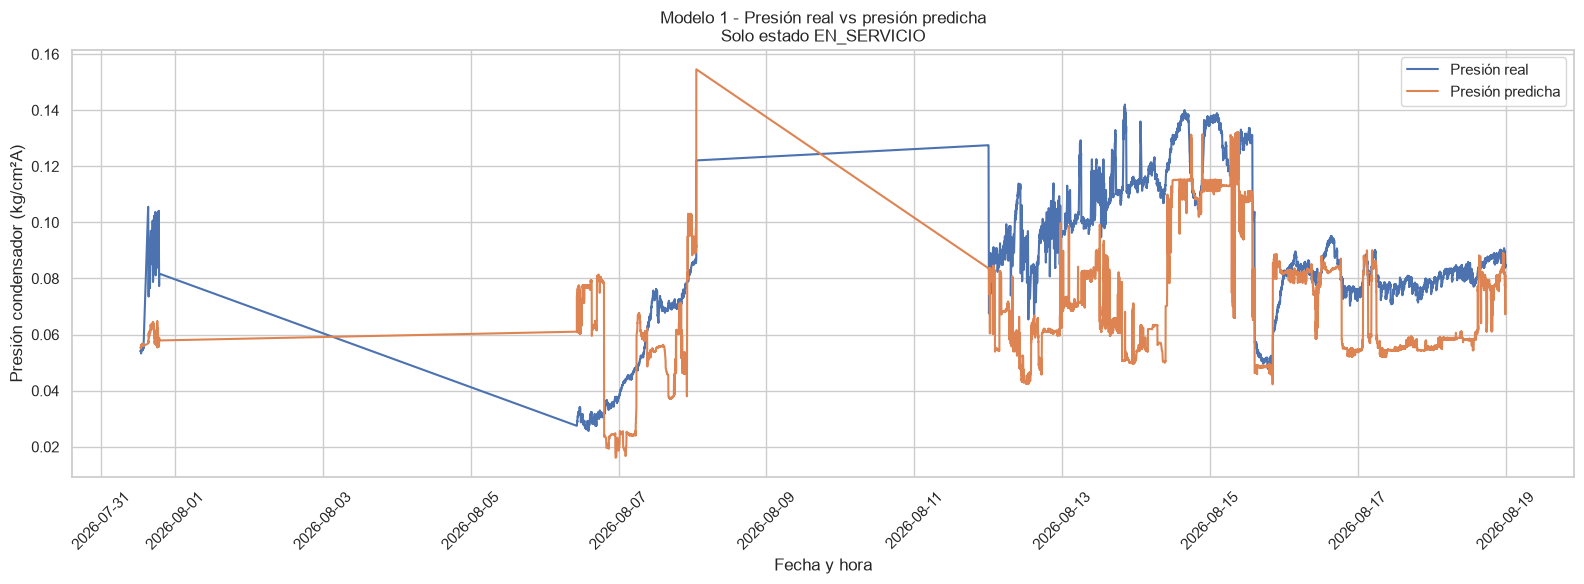

In [17]:
# ============================================================
# 10. GRÁFICO PRESIÓN REAL VS PREDICHA
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=resultado_test,
    x="FechaHora",
    y=objetivo,
    label="Presión real"
)

sns.lineplot(
    data=resultado_test,
    x="FechaHora",
    y="Presion_Predicha",
    label="Presión predicha"
)

plt.xlabel("Fecha y hora")
plt.ylabel("Presión condensador (kg/cm²A)")
plt.title(
    "Modelo 1 - Presión real vs presión predicha\n"
    "Solo estado EN_SERVICIO"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 11. COMPARACIÓN DE MODELOS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# MODELOS
# ============================================================

modelos = {

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        random_state=42
    )
}


# ============================================================
# ENTRENAR Y EVALUAR
# ============================================================

resultados_modelos = []

predicciones_modelos = {}

for nombre, modelo in modelos.items():

    print(f"Entrenando: {nombre}")

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)

    # Guardar predicciones
    predicciones_modelos[nombre] = pred

    # Métricas
    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    r2 = r2_score(y_test, pred)

    resultados_modelos.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# ============================================================
# TABLA DE RESULTADOS
# ============================================================

resultados_modelos = pd.DataFrame(resultados_modelos)

resultados_modelos = (
    resultados_modelos
    .sort_values("RMSE")
    .reset_index(drop=True)
)

resultados_modelos

Entrenando: Random Forest
Entrenando: Extra Trees
Entrenando: Gradient Boosting
Entrenando: Hist Gradient Boosting


,Modelo,MAE,RMSE,R2
0,Extra Trees,0.016694,0.020505,0.386145
1,Gradient Boosting,0.016207,0.021223,0.342409
2,Hist Gradient Boosting,0.017158,0.021692,0.313007
3,Random Forest,0.023224,0.028513,-0.186913


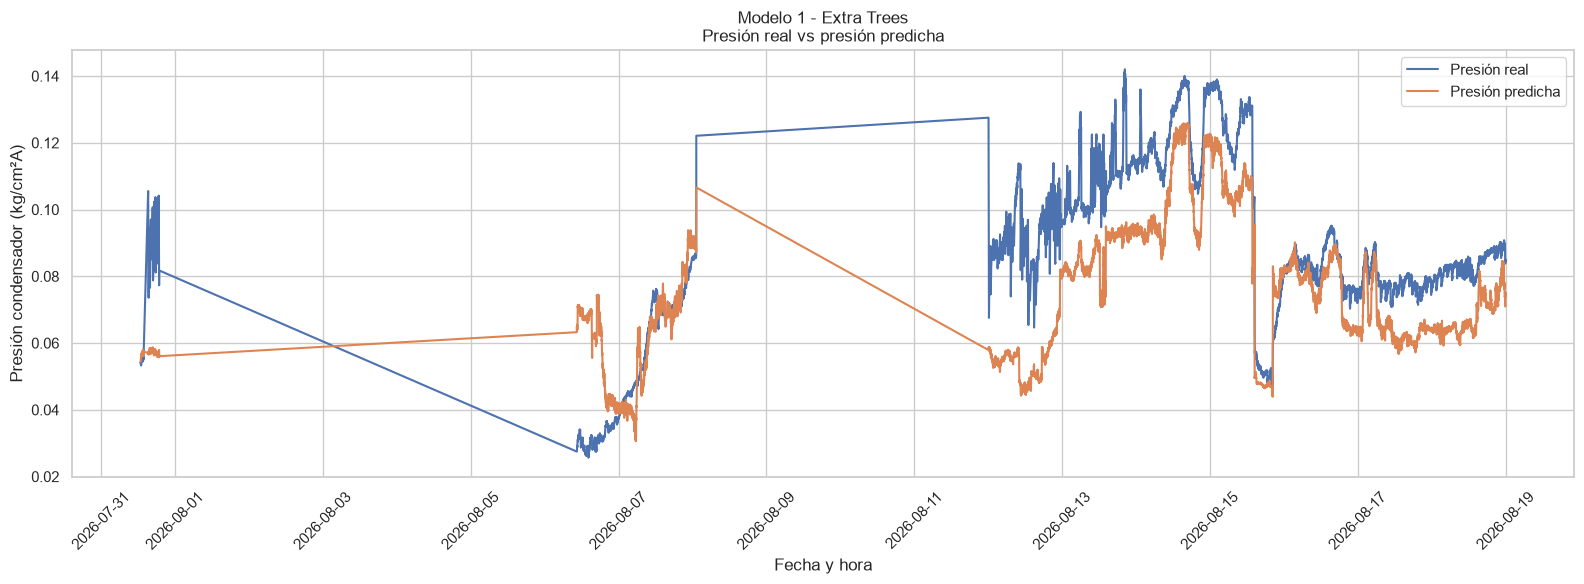

In [19]:
# ============================================================
# PRESIÓN REAL VS PREDICHA - EXTRA TREES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Recuperar predicción de Extra Trees
pred_extra = predicciones_modelos["Extra Trees"]

# Crear dataframe
resultado_extra = test[["FechaHora", objetivo]].copy()

resultado_extra["Presion_Predicha"] = pred_extra

resultado_extra["Error_Absoluto"] = abs(
    resultado_extra[objetivo] -
    resultado_extra["Presion_Predicha"]
)


# ============================================================
# GRÁFICO
# ============================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=resultado_extra,
    x="FechaHora",
    y=objetivo,
    label="Presión real"
)

sns.lineplot(
    data=resultado_extra,
    x="FechaHora",
    y="Presion_Predicha",
    label="Presión predicha"
)

plt.xlabel("Fecha y hora")
plt.ylabel("Presión condensador (kg/cm²A)")

plt.title(
    "Modelo 1 - Extra Trees\n"
    "Presión real vs presión predicha"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()